In [1]:
# Standalone inference notebook for house_model.pth (no dependency on training notebook)

from pathlib import Path
from typing import List, Tuple

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

In [3]:
# Configuration (edit these paths if needed)
MODEL_PATH = Path("house_model_snd.pth")
DEFAULT_IMAGE_PATH = Path("im3.jpg")
DEFAULT_IMAGES_FOLDER = Path("data/custom")

# Class order must match training order
CLASS_NAMES = ["house", "not_house"]

# Force CPU to avoid CUDA compatibility errors
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH.resolve()}")
print("Model path:", MODEL_PATH.resolve())

Using device: cpu
Model path: /home/marwen/Desktop/WEB_PROJECT/aimicroservice/models-training/house_model_snd.pth


In [4]:
# Build model architecture and load trained weights
def load_house_model(model_path: Path, device: torch.device) -> nn.Module:
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 2)  # 2 classes: house, not_house

    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

model = load_house_model(MODEL_PATH, DEVICE)
print("Model loaded successfully.")

Model loaded successfully.


In [5]:
# Preprocessing used during inference (must match training preprocessing)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def predict_image(
    image_path: Path | str,
    model: nn.Module,
    transform: transforms.Compose,
    class_names: List[str],
    device: torch.device,
    show: bool = False,
    ) -> Tuple[str, torch.Tensor]:
    image_path = Path(image_path)  # Accept both string and Path inputs
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu()

    pred_idx = int(torch.argmax(probs).item())
    pred_label = class_names[pred_idx]

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.title(f"Prediction: {pred_label}")
        plt.axis("off")
        plt.show()

    return pred_label, probs

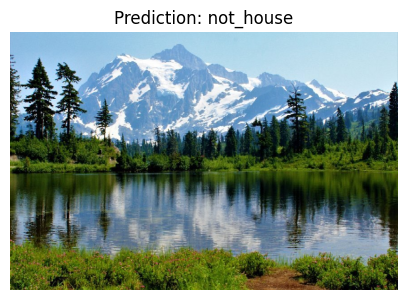

Image: picture-lake.jpg
Prediction: not_house
  house: 0.0045
  not_house: 0.9955


In [12]:
# Test a single image
image_path = Path("picture-lake.jpg")  # change to your image path
pred_label, probs = predict_image(
    image_path=image_path,
    model=model,
    transform=inference_transform,
    class_names=CLASS_NAMES,
    device=DEVICE,
    show=True,
    )

print(f"Image: {image_path}")
print(f"Prediction: {pred_label}")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c}: {probs[i].item():.4f}")